# 04-gene-usage

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import gzip
import shutil
import warnings
warnings.filterwarnings('ignore')

DATA = Path("data")
LN5 = DATA / "LN5"
LT5 = DATA / "LT5"

Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
def extract_file(path: Path) -> Path:
  extracted = Path(str(path).partition(".gz")[0])

  with gzip.open(path, 'rb') as f_in:
    with open(extracted, 'wb') as f_out:
      shutil.copyfileobj(f_in, f_out)

  return extracted

def extract_mtx_data(dir: Path, prefix: str):
  extract_file(dir / f"{prefix}barcodes.tsv.gz")
  extract_file(dir / f"{prefix}genes.tsv.gz")
  extract_file(dir / f"{prefix}matrix.mtx.gz")

In [3]:
def read_sample(dir: Path, prefix: str) -> mu.MuData:
  extract_mtx_data(dir, prefix)

  adata = sc.read_10x_mtx(dir, prefix=prefix)
  adata.var_names_make_unique()
  adata_tcr = ir.io.read_10x_vdj(dir / f"{prefix}filtered_contig_annotations.csv.gz")

  mdata = mu.MuData({'gex': adata, 'airr': adata_tcr})
  mdata['gex'].obs['sample'] = str(dir)
  mdata.update()

  return mdata


In [4]:
ln5 = read_sample(LN5, "GSM4143664_SAM24360810-ln5.")
lt5 = read_sample(LT5, "GSM4143663_SAM24360809-lt5.")

In [5]:
gex  = ad.concat(
  {'lt5': lt5['gex'], 'ln5': ln5['gex']},
  label='sample_id',
  index_unique='-',
  join='outer',
)

airr = ad.concat(
  {'lt5': lt5['airr'], 'ln5': ln5['airr']},
  label='sample_id',
  index_unique='-',
  join='outer',
)

mdata = mu.MuData({'gex': gex, 'airr': airr})
mdata.update()
mdata

MuData object with n_obs × n_vars = 12932 × 30727
  2 modalities
    gex:	11008 × 30727
      obs:	'sample', 'sample_id'
    airr:	7442 × 0
      obs:	'sample_id'
      obsm:	'airr'

In [6]:
sc.pp.filter_genes(mdata["gex"], min_cells=10)
sc.pp.filter_cells(mdata["gex"], min_genes=100)
mdata

MuData object with n_obs × n_vars = 12932 × 30727
  2 modalities
    gex:	11008 × 15068
      obs:	'sample', 'sample_id', 'n_genes'
      var:	'n_cells'
    airr:	7442 × 0
      obs:	'sample_id'
      obsm:	'airr'

In [7]:
sc.pp.normalize_per_cell(mdata["gex"])
sc.pp.log1p(mdata["gex"])
sc.pp.highly_variable_genes(mdata["gex"], flavor="cell_ranger", n_top_genes=5000)
sc.tl.pca(mdata["gex"])
sc.pp.neighbors(mdata["gex"])
sc.tl.umap(mdata["gex"])
mdata.update()
mdata

MuData object with n_obs × n_vars = 12932 × 15068
  2 modalities
    gex:	11008 × 15068
      obs:	'sample', 'sample_id', 'n_genes', 'n_counts'
      var:	'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    airr:	7442 × 0
      obs:	'sample_id'
      obsm:	'airr'

In [8]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

In [9]:
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["no IR", "orphan VDJ", "orphan VJ", "multichain"]))

In [10]:
mdata.obs.groupby("airr:chain_pairing").count()

,gex:sample,gex:sample_id,gex:n_genes,gex:n_counts,airr:sample_id,airr:receptor_type,airr:receptor_subtype
airr:chain_pairing,,,,,,,
extra VDJ,182,182,182,182,194,194,194
extra VJ,196,196,196,196,232,232,232
single pair,3302,3302,3302,3302,4406,4406,4406
two full chains,35,35,35,35,35,35,35


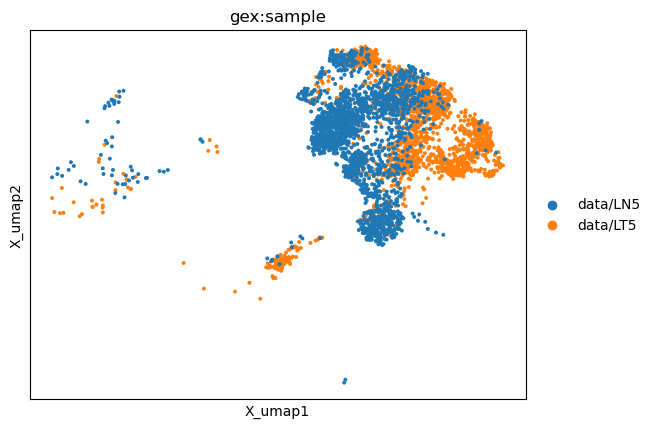

In [11]:
mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color=["gex:sample"],
  ncols=3,
  wspace=0.7,
)

In [12]:
with ir.get.airr_context(mdata, "v_call"):
  obs = mdata.obs[mdata.obs["gex:sample_id"] == "lt5"]
  obs = obs.groupby("VJ_1_v_call").count().sort_values("gex:sample", ascending=False)
  dominant_alpha_lt5 = obs.head(1).index.item()
  print(f"Most abundant dominant LT5 alpha-chain gene: {dominant_alpha_lt5}")

  obs = mdata.obs[mdata.obs["gex:sample_id"] == "lt5"]
  obs = obs.groupby("VJ_2_v_call").count().sort_values("gex:sample", ascending=False)
  secondary_alpha_lt5 = obs.head(1).index.item()
  print(f"Most abundant secondary LT5 alpha-chain gene: {secondary_alpha_lt5}")

Most abundant dominant LT5 alpha-chain gene: TRAV12-2
Most abundant secondary LT5 alpha-chain gene: TRAV26-1


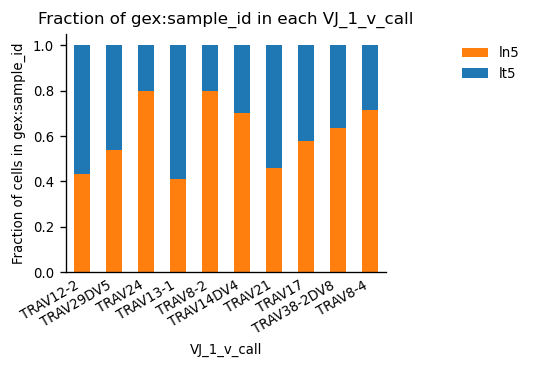

In [13]:
with ir.get.airr_context(mdata, "v_call"):
  ir.pl.group_abundance(
    mdata,
    groupby="VJ_1_v_call",
    target_col="gex:sample_id",
    normalize=True,
    max_cols=10,
  )

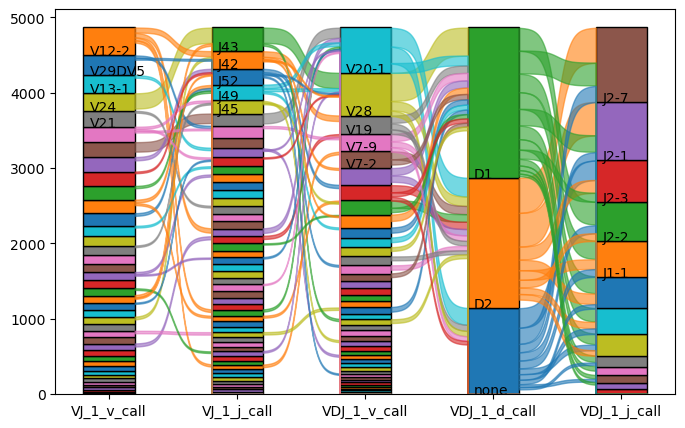

In [14]:
_ = ir.pl.vdj_usage(
    mdata,
    full_combination=False,
    max_segments=None,
    max_ribbons=30,
    fig_kws={"figsize": (8, 5)},
)

In [15]:
output = {
  "dominant_alpha_lt5": dominant_alpha_lt5,
  "secondary_alpha_lt5": secondary_alpha_lt5,
  "trav14dv4_usage": "LN5",
  "most_abundant_beta_chain_d_gene": "TRBD2"
}

print(json.dumps(output, indent=2))

# with open('output.json', 'w') as f:
#     json.dump(output, f, indent=2)
# print('Results saved to output.json:')

{
  "dominant_alpha_lt5": "TRAV12-2",
  "secondary_alpha_lt5": "TRAV26-1",
  "trav14dv4_usage": "LN5",
  "most_abundant_beta_chain_d_gene": "TRBD2"
}
